In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('CarsData.csv')
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Manufacturer
0,I10,2017,7495,Manual,11630,Petrol,145,60.1,1.0,hyundi
1,Polo,2017,10989,Manual,9200,Petrol,145,58.9,1.0,volkswagen
2,2 Series,2019,27990,Semi-Auto,1614,Diesel,145,49.6,2.0,BMW
3,Yeti Outdoor,2017,12495,Manual,30960,Diesel,150,62.8,2.0,skoda
4,Fiesta,2017,7999,Manual,19353,Petrol,125,54.3,1.2,ford
...,...,...,...,...,...,...,...,...,...,...
97707,Fiesta,2017,10447,Automatic,8337,Petrol,145,54.3,1.0,ford
97708,3 Series,2014,14995,Manual,25372,Diesel,30,61.4,2.0,BMW
97709,Fiesta,2017,8950,Manual,19910,Petrol,125,54.3,1.2,ford
97710,Astra,2017,10700,Automatic,24468,Petrol,125,50.4,1.4,vauxhall


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 97712 entries, 0 to 97711
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         97712 non-null  str    
 1   year          97712 non-null  int64  
 2   price         97712 non-null  int64  
 3   transmission  97712 non-null  str    
 4   mileage       97712 non-null  int64  
 5   fuelType      97712 non-null  str    
 6   tax           97712 non-null  int64  
 7   mpg           97712 non-null  float64
 8   engineSize    97712 non-null  float64
 9   Manufacturer  97712 non-null  str    
dtypes: float64(2), int64(4), str(4)
memory usage: 7.5 MB


In [5]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,97712.000000,97712.000000,97712.000000,97712.000000,97712.000000,97712.000000
mean,2017.066502,16773.487555,23219.475499,120.142408,55.205623,1.664913
std,2.118661,9868.552222,21060.882301,63.357250,16.181659,0.558574
min,1970.000000,450.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,9999.000000,7673.000000,125.000000,47.100000,1.200000
50%,2017.000000,14470.000000,17682.500000,145.000000,54.300000,1.600000
75%,2019.000000,20750.000000,32500.000000,145.000000,62.800000,2.000000
max,2024.000000,159999.000000,323000.000000,580.000000,470.800000,6.600000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Manufacturer    0
dtype: int64

In [10]:
df.nunique()


model             196
year               27
price           13236
transmission        4
mileage         42214
fuelType            5
tax                48
mpg               208
engineSize         40
Manufacturer        9
dtype: int64

In [11]:
df['Manufacturer'].value_counts()


Manufacturer
ford          17811
volkswagen    14893
vauxhall      13258
merc          12860
BMW           10664
Audi          10565
toyota         6699
skoda          6188
hyundi         4774
Name: count, dtype: int64

In [12]:
df['model'].value_counts()


model
 Fiesta     6509
 Golf       4797
 Focus      4555
 C Class    3694
 Corsa      3285
            ... 
 A2            1
 Amica         1
 RS7           1
 Accent        1
220            1
Name: count, Length: 196, dtype: int64

In [13]:
df['fuelType'].value_counts()


fuelType
Petrol      53982
Diesel      40419
Hybrid       3059
Other         246
Electric        6
Name: count, dtype: int64

In [14]:
df['transmission'].value_counts()


transmission
Manual       55502
Semi-Auto    22296
Automatic    19905
Other            9
Name: count, dtype: int64

### EDA (Exploratory Data Analysis)

In [16]:
# Select all numerical and categorical columns
num_cols = df.select_dtypes(include = ['float','int']).columns
cat_cols = df.select_dtypes(include = ['object','category']).columns

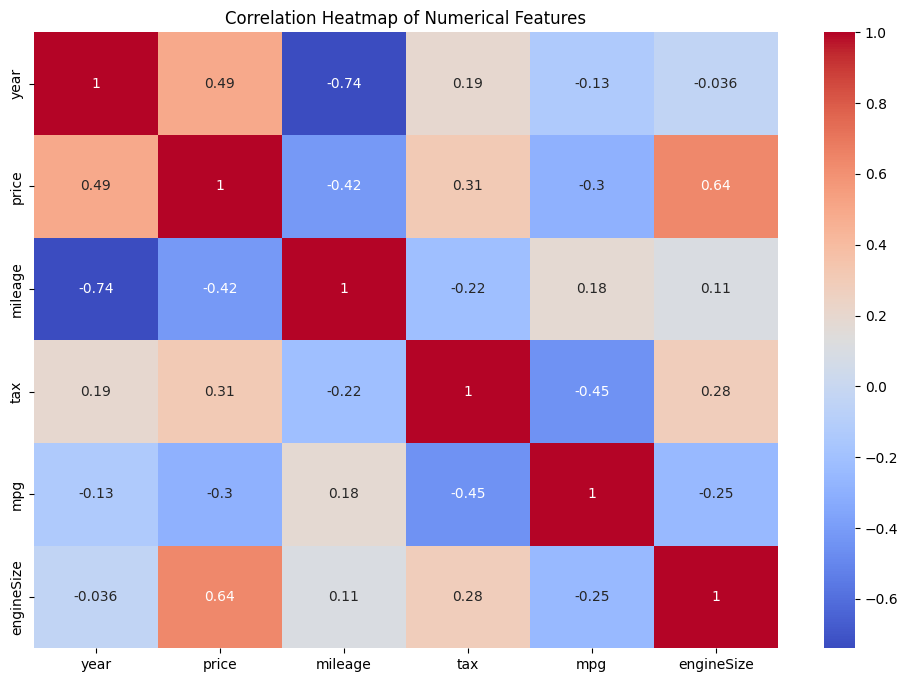

In [17]:
# Correlation heatmap for numerical features
corr = df[num_cols].corr()
plt.figure(figsize = (12,8))
sns.heatmap(corr,cmap = 'coolwarm', annot = True)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

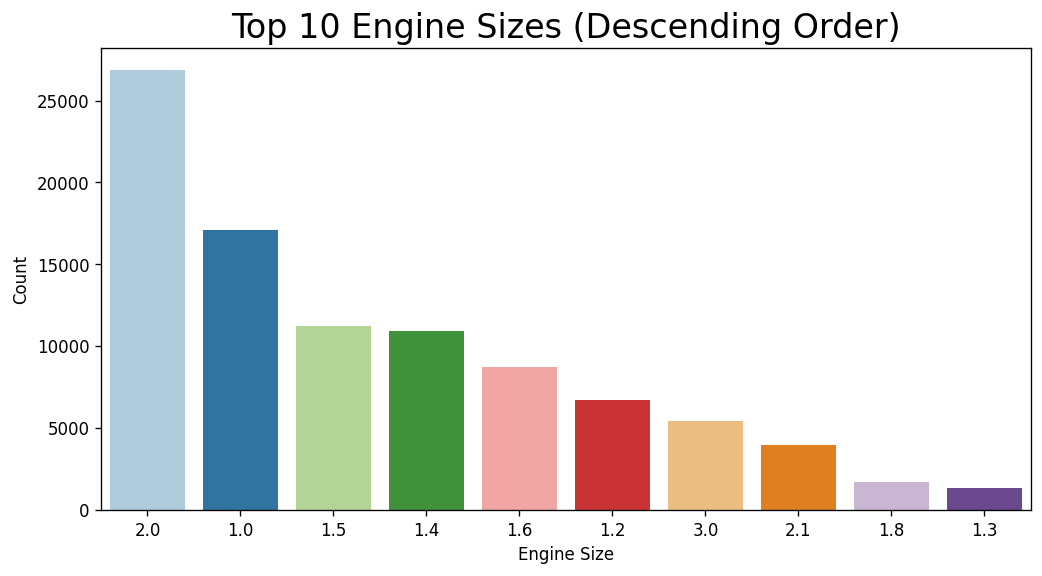

In [18]:
# Count the frequency of each engine size
engine_size_counts = df['engineSize'].value_counts()

# Sort the engine sizes in descending order of frequency
engine_size_counts_sorted = engine_size_counts.sort_values(ascending=False)

# Select the top 10 engine sizes
top_10_engine_sizes = engine_size_counts_sorted.head(10)

# Create the bar plot
plt.figure(figsize=(10, 5), dpi=120)
sns.countplot(data=df[df['engineSize'].isin(top_10_engine_sizes.index)], x='engineSize', order=top_10_engine_sizes.index, palette='Paired')
plt.title("Top 10 Engine Sizes (Descending Order)", fontsize=20)
plt.xlabel("Engine Size")
plt.ylabel("Count")
plt.show()

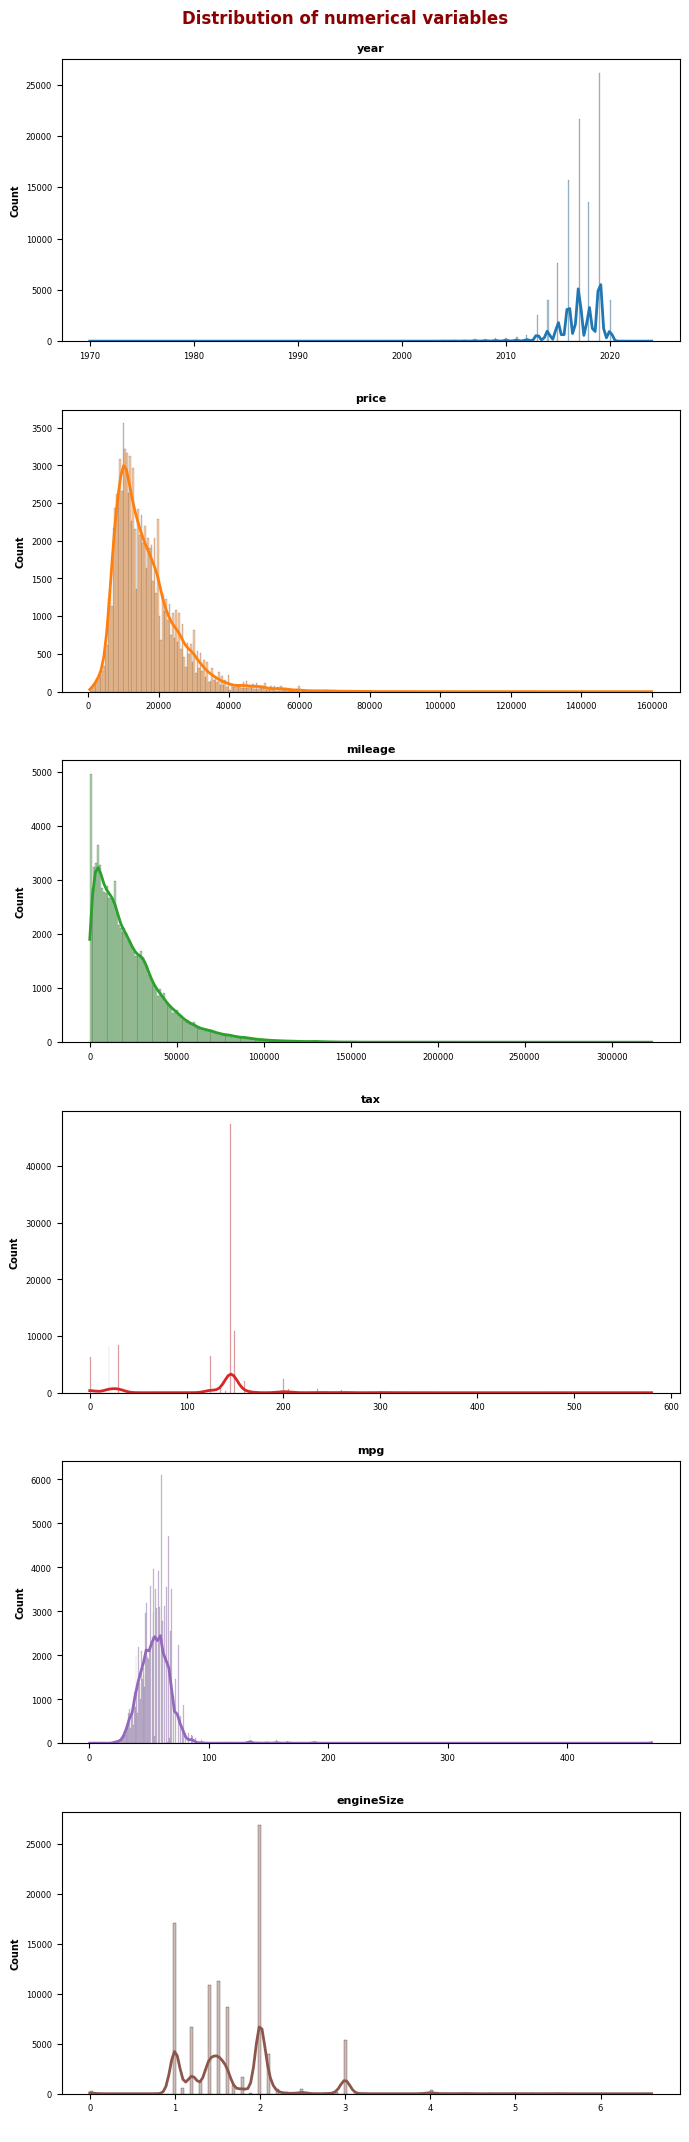

In [34]:
# Distribution of Numerical Variables
fig,axes = plt.subplots(7, 1, figsize = (7, 25))
axes = axes.flat

for i, num_col in enumerate(num_cols):
  sns.histplot(df,
               x = num_col,
               stat = 'count',
               kde = True,
               color = (list(plt.rcParams['axes.prop_cycle'])*2)[i]["color"],
               line_kws = {'linewidth': 2},
               alpha = 0.4,
               ax = axes[i])

  axes[i].set_xlabel(" ")
  axes[i].set_ylabel("Count", fontsize = 7, fontweight = 'bold', color = 'black')
  axes[i].set_title(num_col, fontsize = 8, fontweight = 'bold', color = 'black')
  axes[i].tick_params(labelsize = 6)


fig.delaxes(axes[6])
fig.suptitle('Distribution of numerical variables', fontsize = 12, fontweight = 'bold', color = 'darkred')
fig.tight_layout()
fig.subplots_adjust(top = 0.96)
fig.show()

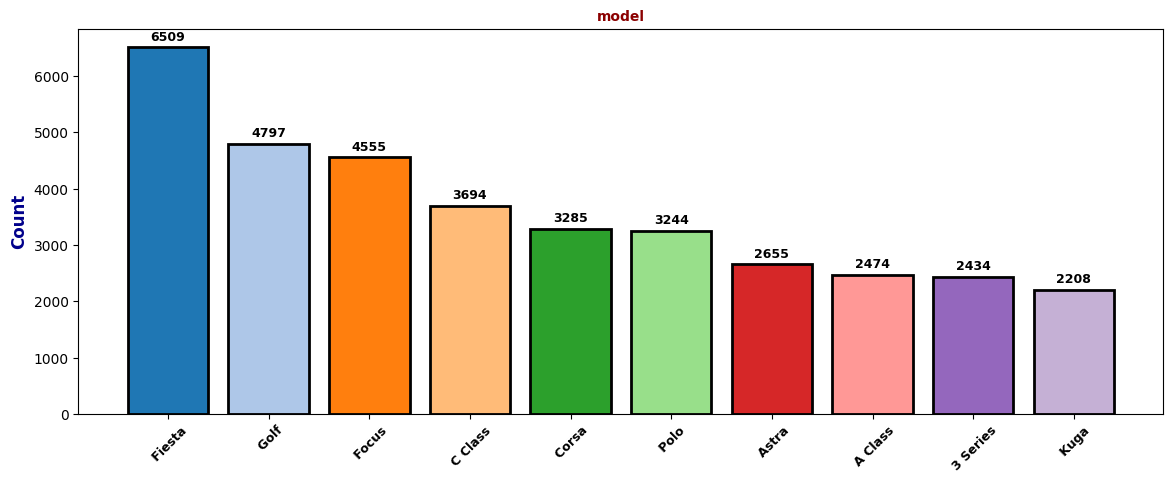

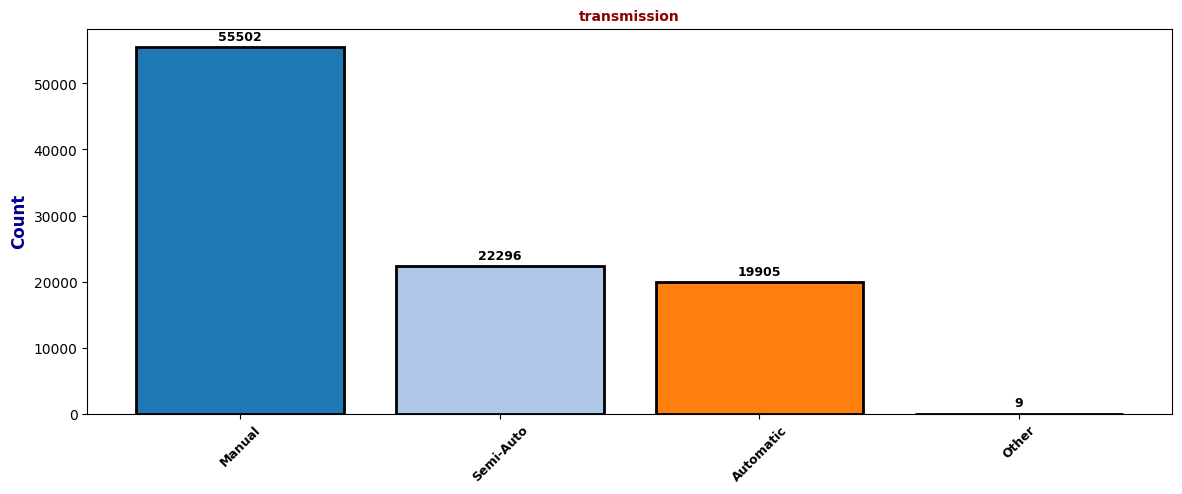

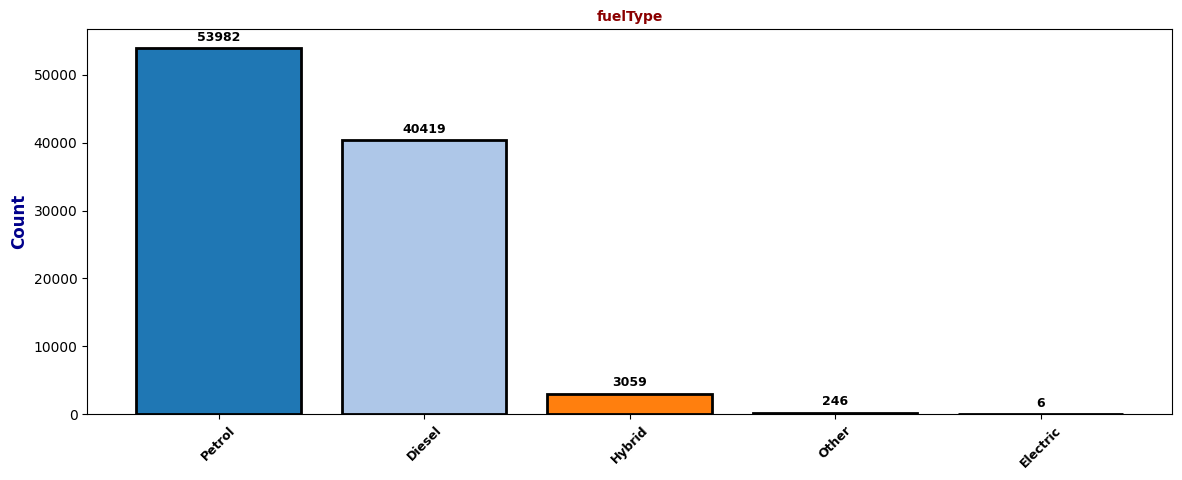

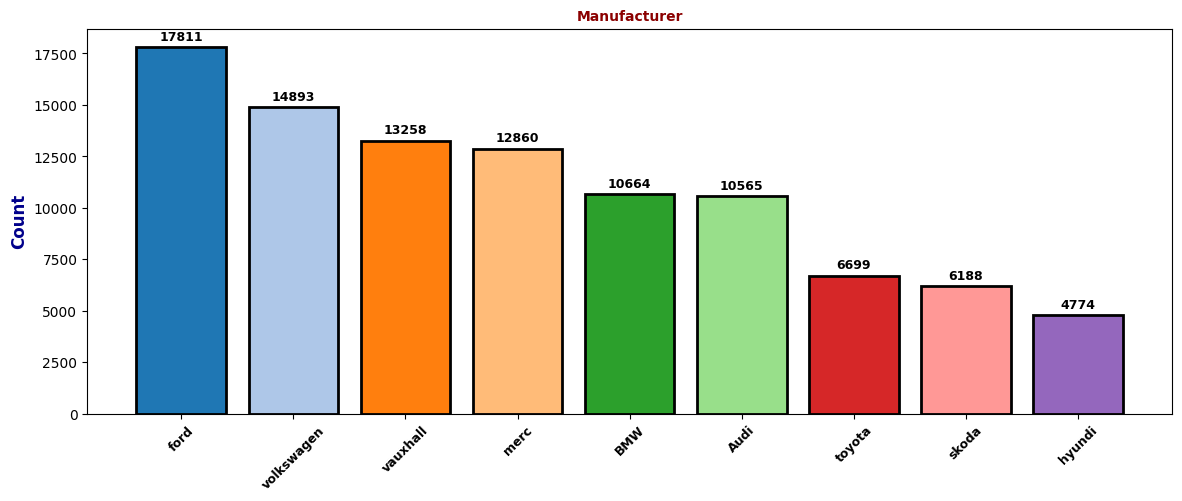

In [35]:
# Distribution of Categorical Variables
cols = [0, 1, 2, 3]

for i in cols:

        if i == 0:

            # We define the size of our figure.
            fig,ax = plt.subplots(figsize=(14,5))

            # 1. We create our dataframe that contains our data to be displayed.
            df_name = df[cat_cols[0]].value_counts().to_frame().head(10)

            # 2.  Extract frequency values for plotting.
            values = df_name.iloc[:,0]
            # 3. We generate the labels for our charts.
            labels = df_name.index.to_list()
            # 4. We generate the color map.
            cmap = plt.get_cmap('tab20')
            colors = cmap(np.arange(len(labels)))


            # 2. Bar chart.
            rects = ax.bar(labels, values, color = colors,
                              edgecolor = 'black', linewidth = 2.0)

            ax.set_title(f"{cat_cols[0]}", fontsize = 10, fontweight = 'bold', color = 'darkred')
            ax.set_ylabel('Count', fontsize = 12, fontweight = 'bold', color = 'darkblue')
            ax.set_xticklabels(labels, fontsize = 9, fontweight = 'bold', rotation = 45)

            # function to label our bars.
            def autolabel(rects):
              for rect in rects:
                height = rect.get_height()
                ax.annotate(text = '{}'.format(height),
                            xy = (rect.get_x() + rect.get_width()/2., height-0.005),
                            xytext = (0,3),
                            textcoords = 'offset points',
                            va = 'bottom',
                            ha = 'center',
                            weight = 'bold',
                            size = 9,
                            color = 'black')

            autolabel(rects) # we label our bars.

            fig.show()
            
        else:
            
            # We define the size of our figure.
            fig,ax = plt.subplots(figsize=(14,5))

            # 1. We create our dataframe that contains our data to be displayed.
            df_name = df[cat_cols[i]].value_counts().to_frame().head(10)

            # 2. We generate the values of our graphs.
            values = df_name.iloc[:,0]
            # 3. We generate the labels for our charts.
            labels = df_name.index.to_list()
            # 4. We generate the color map.
            cmap = plt.get_cmap('tab20')
            colors = cmap(np.arange(len(labels)))


            # 2. Bar chart.
            rects = ax.bar(labels, values, color = colors,
                              edgecolor = 'black', linewidth = 2.0)

            ax.set_title(f"{cat_cols[i]}", fontsize = 10, fontweight = 'bold', color = 'darkred')
            ax.set_ylabel('Count', fontsize = 12, fontweight = 'bold', color = 'darkblue')
            ax.set_xticklabels(labels, fontsize = 9, fontweight = 'bold', rotation = 45)

            # function to label our bars.
            def autolabel(rects):
              for rect in rects:
                height = rect.get_height()
                ax.annotate(text = '{}'.format(height),
                            xy = (rect.get_x() + rect.get_width()/2., height-0.005),
                            xytext = (0,3),
                            textcoords = 'offset points',
                            va = 'bottom',
                            ha = 'center',
                            weight = 'bold',
                            size = 9,
                            color = 'black')

            autolabel(rects) # we label our bars.

            fig.show()

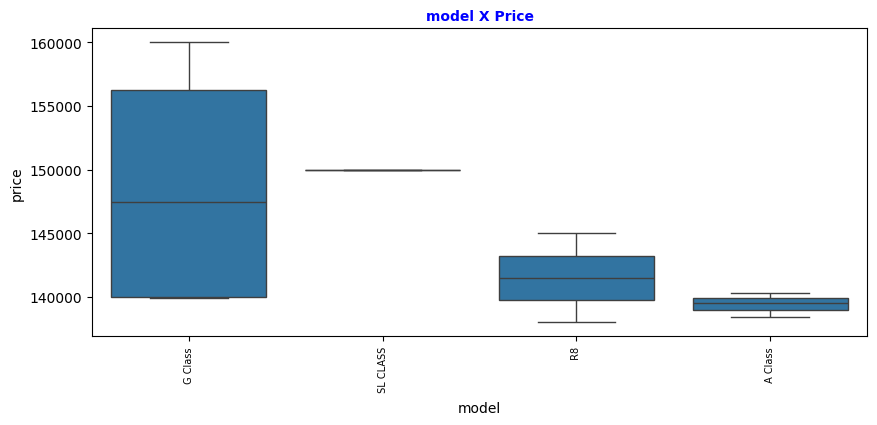

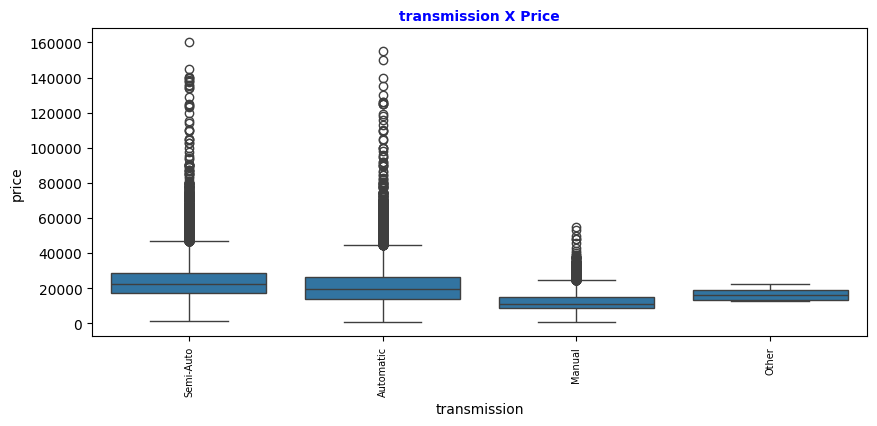

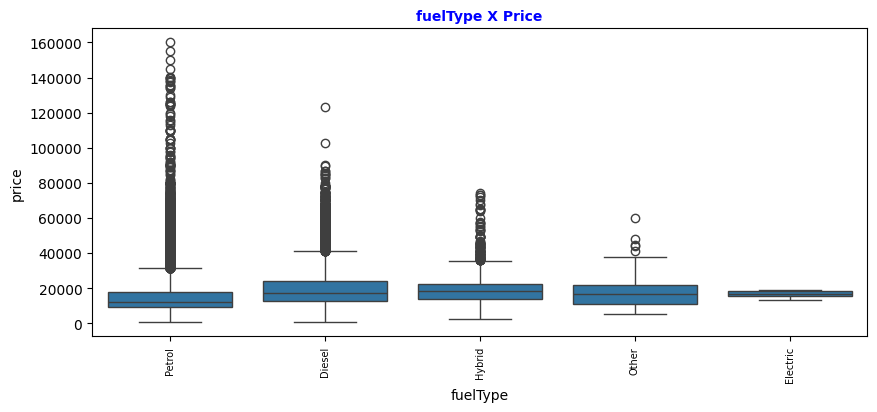

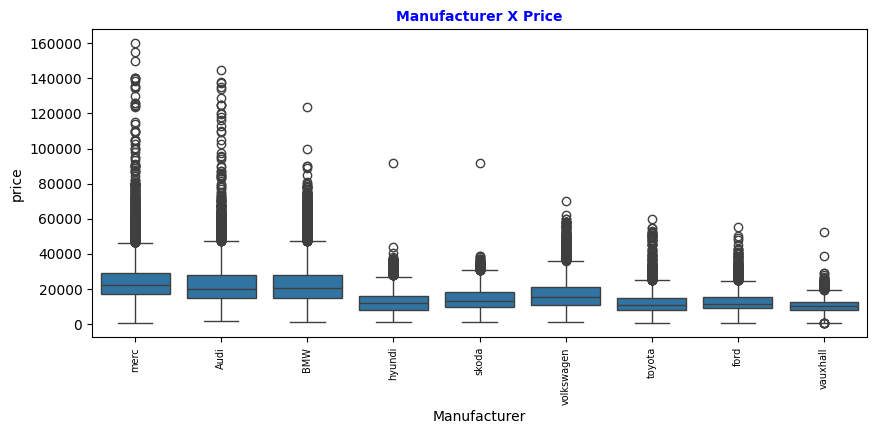

In [36]:
# This code is analyzing how categorical variables affect car price using boxplots.
# Select indices of categorical columns to analyze
cols = [0, 1, 2, 3]

# Sort the dataset by price in descending order
# This helps highlight the most expensive cars
df_top = df.sort_values(["price"], axis=0, ascending=False)

# Loop through selected categorical features
for i in cols:

    # Create a figure for the boxplot
    fig, ax = plt.subplots(figsize=(10,4))

    # Special case for 'model' because there are many unique models
    if i == 0:

        # Plot boxplot of price distribution for top 10 car models
        sns.boxplot(x='model', y='price', data=df_top.head(10))

        # Add title to the plot
        ax.set_title(f"{cat_cols[i]} X Price", fontsize=10, fontweight='bold', color='blue')

        # Rotate x-axis labels for readability
        plt.xticks(rotation=90, fontsize=7)

        plt.show()

    else:

        # Plot price distribution for other categorical variables
        sns.boxplot(x=cat_cols[i], y='price', data=df_top)

        # Add title
        ax.set_title(f"{cat_cols[i]} X Price", fontsize=10, fontweight='bold', color='blue')

        # Rotate labels for readability
        plt.xticks(rotation=90, fontsize=7)

        plt.show()

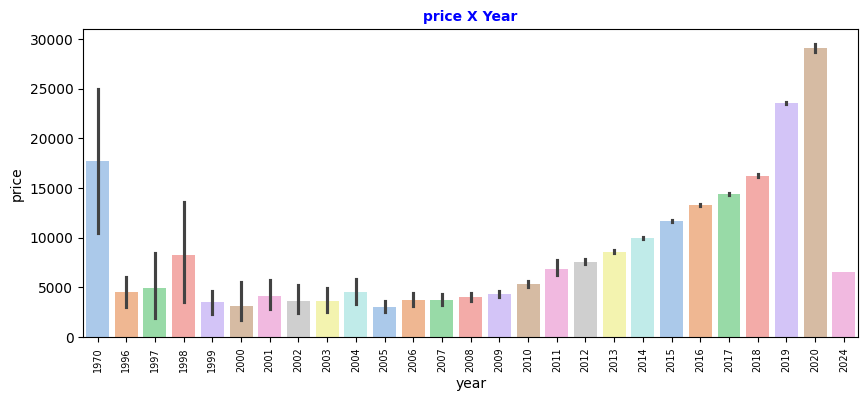

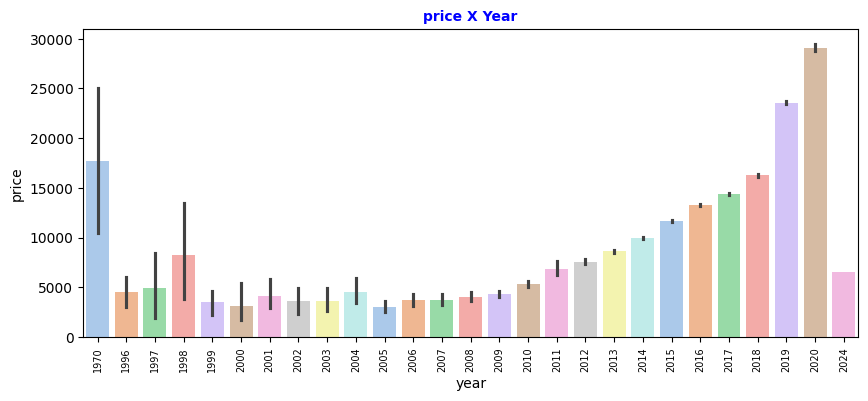

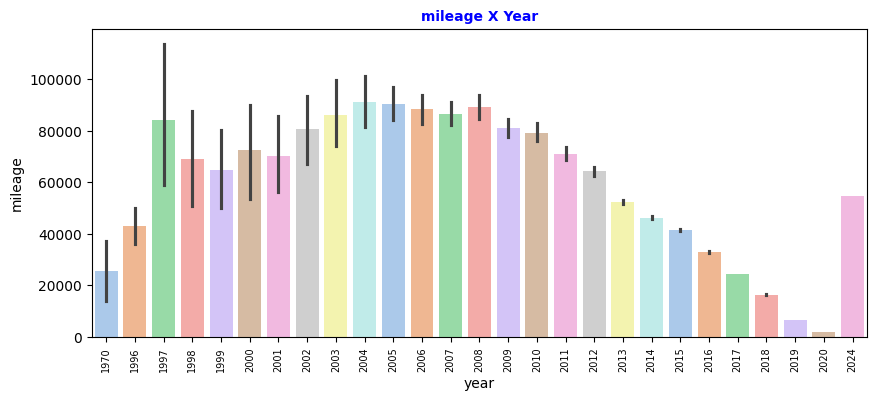

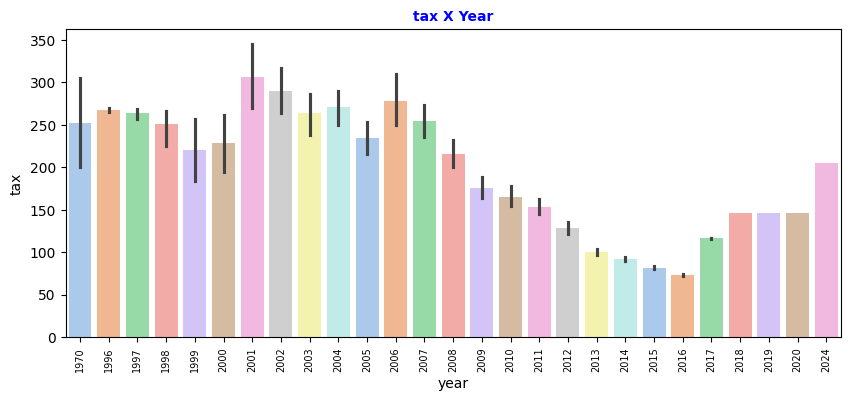

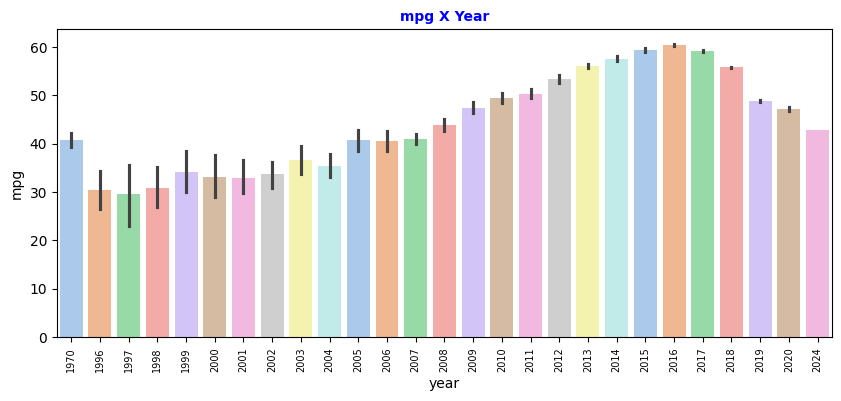

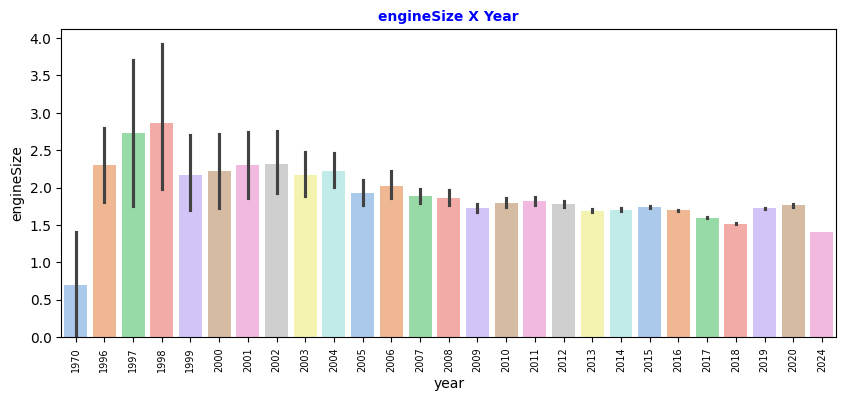

In [37]:
# Analyzing how numerical variables change with respect to the manufacturing year. 
# It creates bar plots comparing year with other numerical features.
for i in num_cols:
        fig, ax = plt.subplots(figsize=(10, 4))

        if i == 'year':
            sns.barplot(data=df, x = 'year', y = 'price', palette="pastel")
            ax.set_title('price'  + " X Year", fontsize = 10, fontweight = 'bold', color = 'blue')
            plt.xticks(rotation=90, fontsize = 7)
            plt.show()
        else:
            sns.barplot(data=df, x = 'year', y = i, palette="pastel")
            ax.set_title(f"{i}"+ " X Year", fontsize = 10, fontweight = 'bold', color = 'blue')
            plt.xticks(rotation=90, fontsize = 7)
            plt.show()

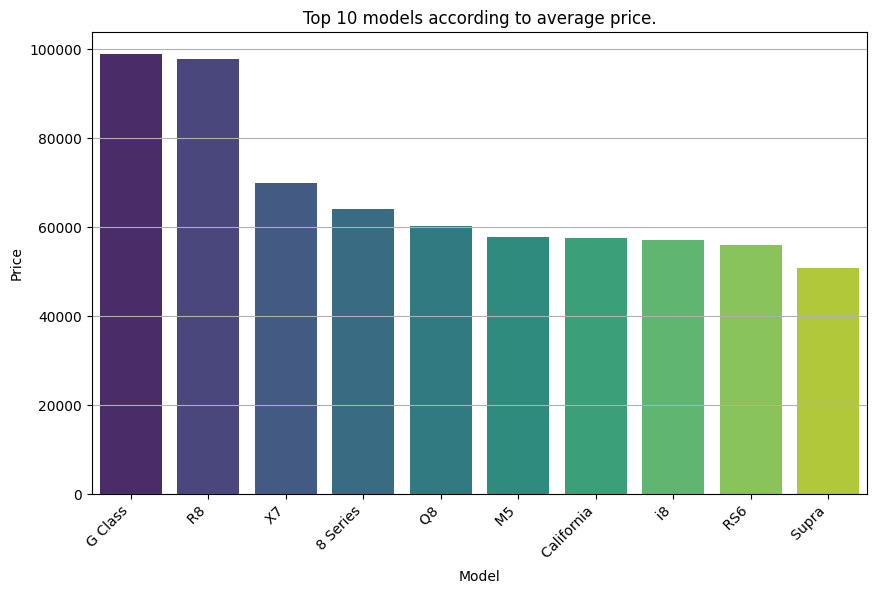

In [38]:
# Analyzing the top 10 most expensive car models based on average price.
char_bar = df.groupby(['model'])[['price']].mean().reset_index()
char_bar = char_bar.sort_values(by=("price"), ascending=False)

top = char_bar.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='model', y='price', data=top, palette='viridis')
plt.title('Top 10 models according to average price.')
plt.xlabel('Model')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()

In [39]:
# Analyzing the price distribution of the 'Fiesta' model.
df_fiesta = df[df['model'] == ' Fiesta']
df_fiesta.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Manufacturer
4,Fiesta,2017,7999,Manual,19353,Petrol,125,54.3,1.2,ford
8,Fiesta,2018,9891,Manual,31639,Petrol,145,65.7,1.0,ford
16,Fiesta,2017,10490,Manual,16087,Petrol,0,65.7,1.0,ford
21,Fiesta,2017,12750,Semi-Auto,12687,Petrol,145,54.3,1.0,ford
30,Fiesta,2018,10500,Manual,13427,Petrol,145,65.7,1.0,ford


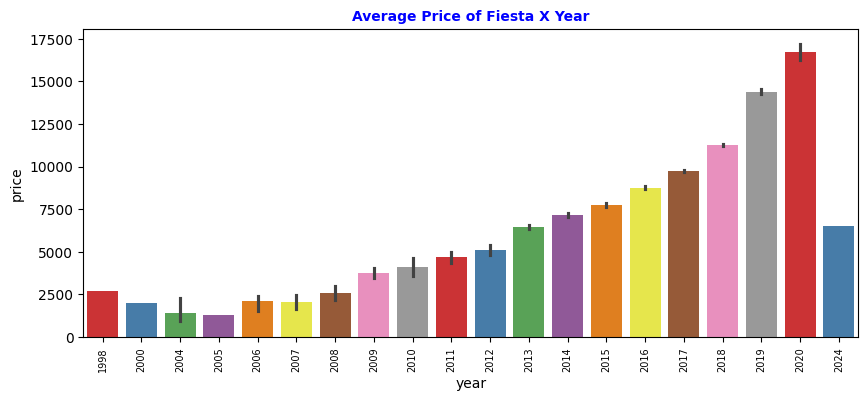

In [40]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=df_fiesta, x = 'year', y = 'price', palette="Set1")
ax.set_title('Average Price of Fiesta X Year', fontsize = 10, fontweight = 'bold', color = 'blue')
plt.xticks(rotation=90, fontsize = 7)
plt.show()

Text(0, 0.5, 'Total Price')

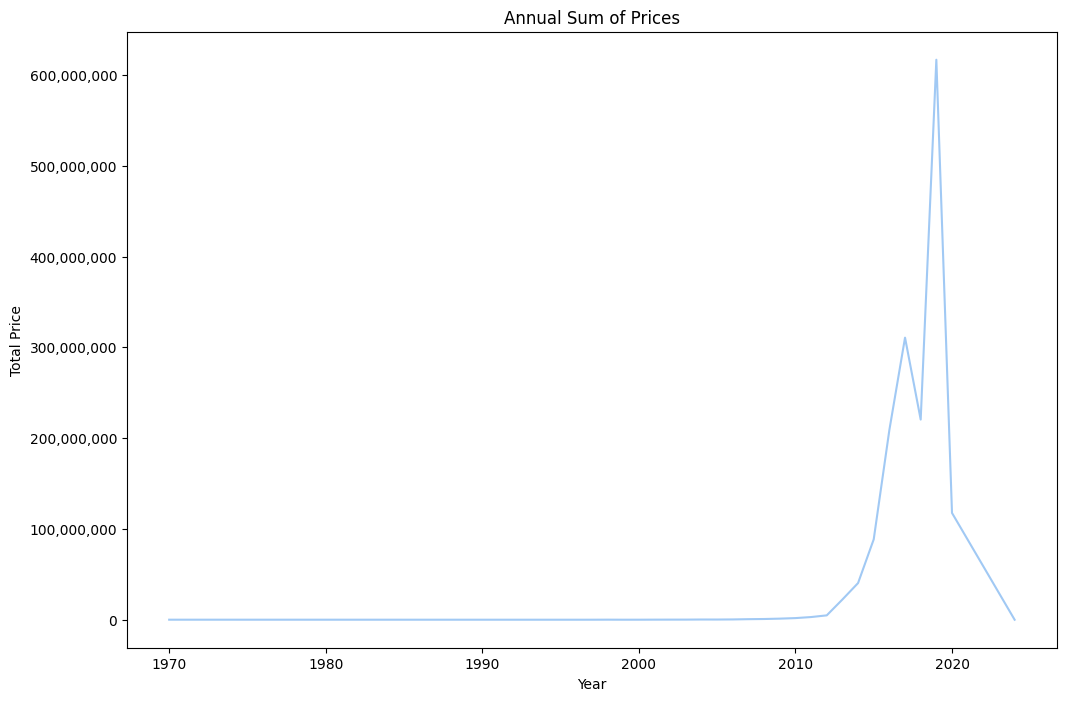

In [42]:
# Analyzing the annual sum of car prices to see how total market value changes over time.

plt.figure(figsize=(12, 8))

# Group the dataset by year and calculate the total price of cars for each year
# Then plot it as a line chart
ax = df.groupby('year')['price'].sum().plot(
    kind='line',
    color=sns.color_palette('pastel')
)

# Format the y-axis numbers with commas (e.g., 1000000 -> 1,000,000)
ax.get_yaxis().set_major_formatter(
    plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)))
)

# Add title and axis labels
plt.title('Annual Sum of Prices')
plt.xlabel('Year')
plt.ylabel('Total Price')

In [43]:
# Rotate x-axis labels for better readability
df_temp = df[df.year > 2015]
df_temp

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Manufacturer
0,I10,2017,7495,Manual,11630,Petrol,145,60.1,1.0,hyundi
1,Polo,2017,10989,Manual,9200,Petrol,145,58.9,1.0,volkswagen
2,2 Series,2019,27990,Semi-Auto,1614,Diesel,145,49.6,2.0,BMW
3,Yeti Outdoor,2017,12495,Manual,30960,Diesel,150,62.8,2.0,skoda
4,Fiesta,2017,7999,Manual,19353,Petrol,125,54.3,1.2,ford
...,...,...,...,...,...,...,...,...,...,...
97705,Kuga,2017,14795,Manual,25570,Diesel,150,60.1,2.0,ford
97707,Fiesta,2017,10447,Automatic,8337,Petrol,145,54.3,1.0,ford
97709,Fiesta,2017,8950,Manual,19910,Petrol,125,54.3,1.2,ford
97710,Astra,2017,10700,Automatic,24468,Petrol,125,50.4,1.4,vauxhall


(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, '2016'),
  Text(1, 0, '2017'),
  Text(2, 0, '2018'),
  Text(3, 0, '2019'),
  Text(4, 0, '2020'),
  Text(5, 0, '2024')])

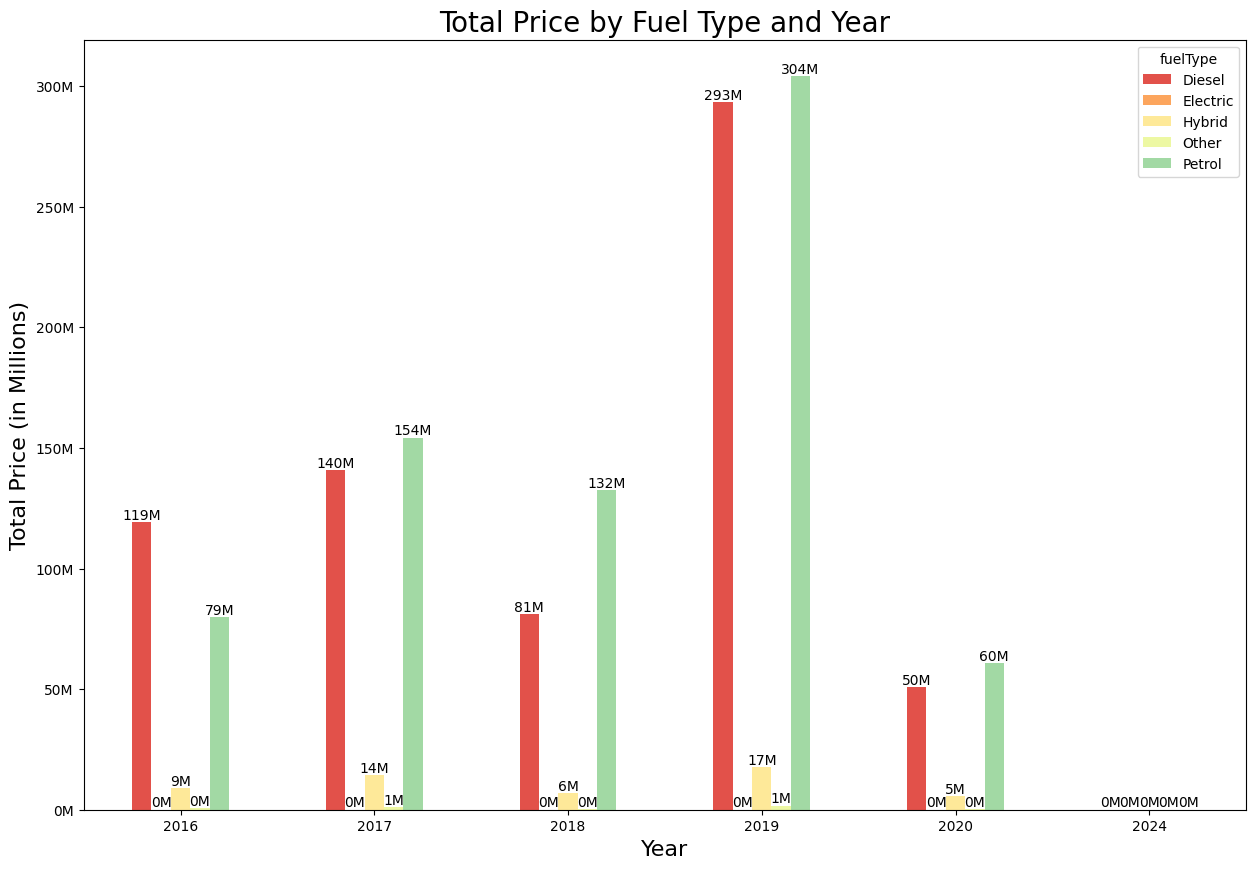

In [44]:
# Analyzing the total price by fuel type and year using a bar plot.
# performing a multi-category analysis of price. 
# It shows how the total price of cars varies by both fuel type and year using a grouped bar chart.
from matplotlib.ticker import FuncFormatter
def millions(x, pos):
    'The two args are the value and tick position'
    return f'{int(x / 1e6)}M'


ax = df_temp.groupby(['year', 'fuelType'])['price'].sum().unstack().plot(
    kind='bar',
    color=sns.color_palette("Spectral"),
    figsize=(15, 10) 
)

formatter = FuncFormatter(millions)

ax.set_title('Total Price by Fuel Type and Year', fontsize=20)
ax.set_xlabel('Year', fontsize=16)
ax.set_ylabel('Total Price (in Millions)', fontsize=16)

ax.yaxis.set_major_formatter(formatter)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height() / 1e6)}M', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.xticks(rotation=0)

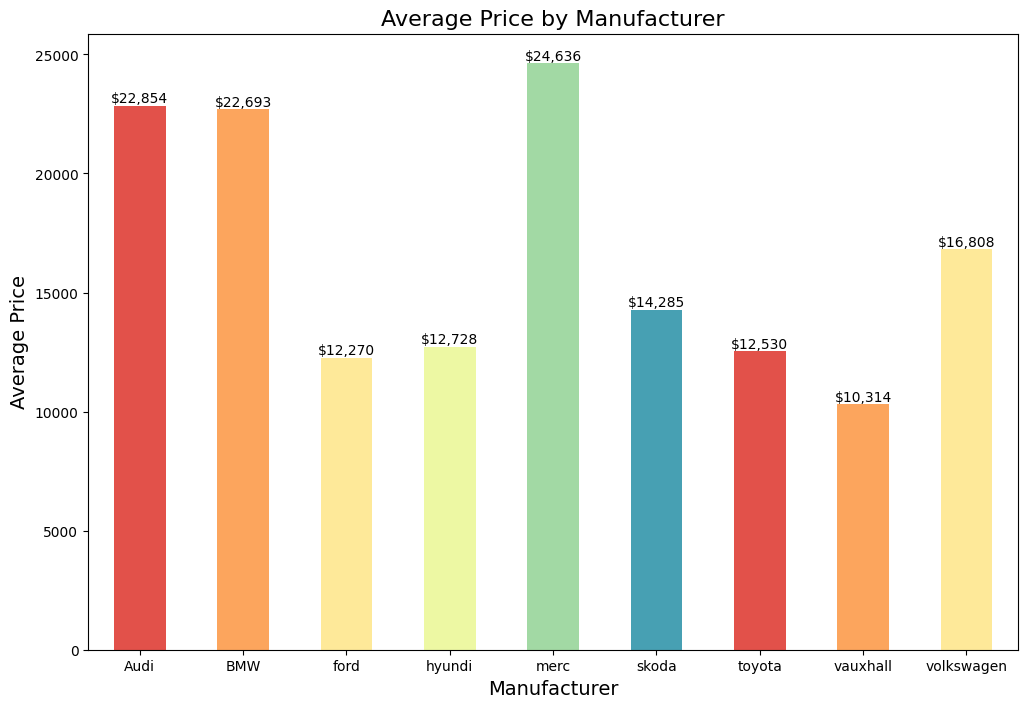

In [45]:
# Analyzing the average price of cars by manufacturer using a bar plot.
plt.figure(figsize=(12, 8))
ax = df.groupby('Manufacturer')['price'].mean().plot(kind='bar', color=sns.color_palette("Spectral"))

ax.set_title('Average Price by Manufacturer', fontsize=16)
ax.set_xlabel('Manufacturer', fontsize=14)
ax.set_ylabel('Average Price', fontsize=14)

plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(f'${p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

In [46]:
# Calculate the total price of cars for each model and sort them from lowest to highest
df.groupby("model")['price'].sum().sort_values()

model
Accent          1295
Amica           1750
A2              2490
Escort          3000
Streetka        3849
              ...   
E Class     48988844
Focus       60030224
Fiesta      66332283
Golf        79811121
C Class     87391114
Name: price, Length: 196, dtype: int64

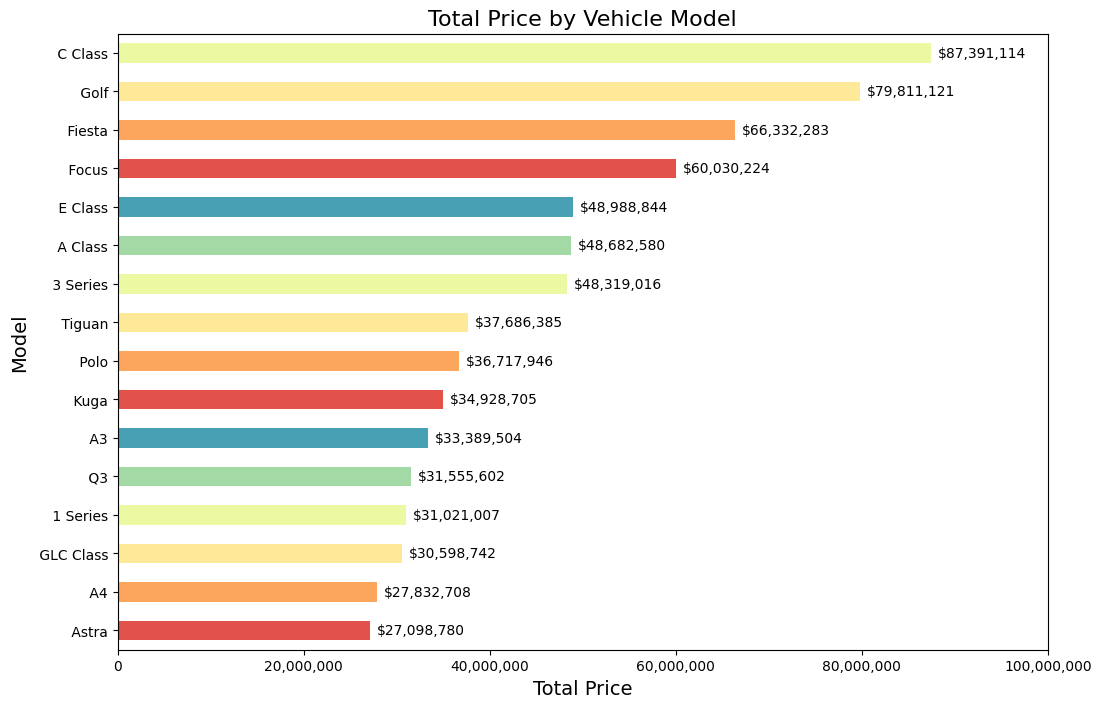

In [47]:
# This code creates a horizontal bar chart showing the total price contribution of different car models. 
# It highlights models whose combined prices sum up to the highest values.
plt.figure(figsize=(12, 8))
ax = df.groupby("model")['price'].sum().sort_values(ascending=False)[15::-1].plot(
    kind='barh',
    color=sns.color_palette("Spectral")
)

ax.set_title('Total Price by Vehicle Model', fontsize=16)
ax.set_xlabel('Total Price', fontsize=14)
ax.set_ylabel('Model', fontsize=14)

ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
for p in ax.patches:
    ax.annotate(f'${p.get_width():,.0f}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, color='black', xytext=(5, 0),
                textcoords='offset points')

ax.set_xlim(0, 100_000_000)
plt.show()

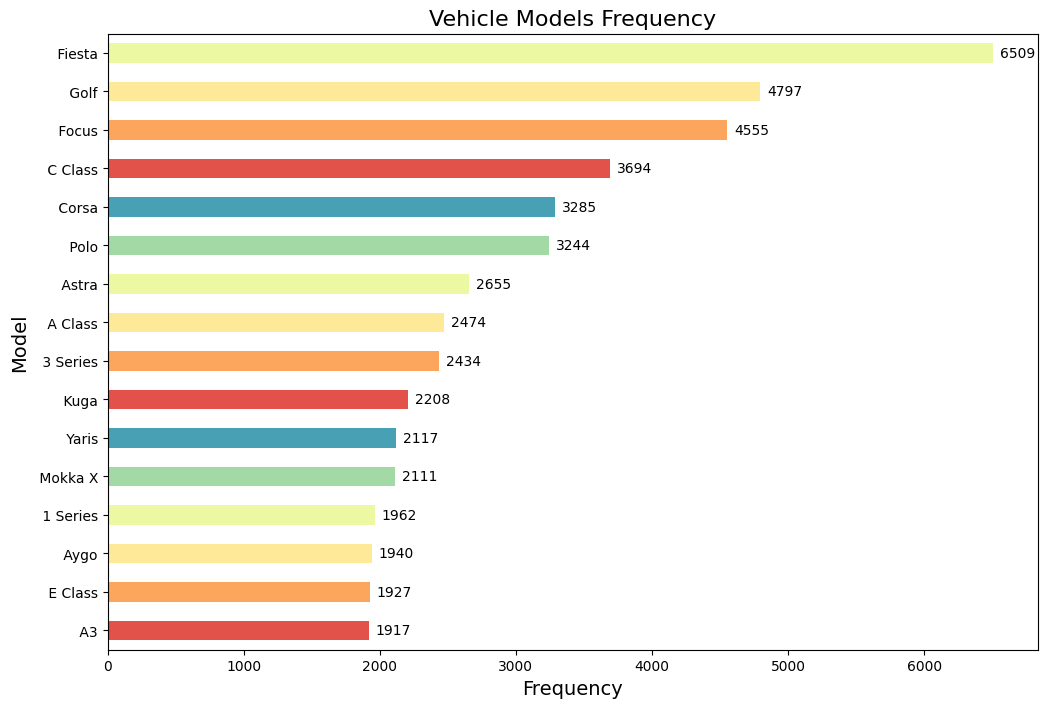

In [48]:
# A frequency analysis of vehicle models was performed to understand the distribution of models in the dataset. 
# The results show that certain models appear significantly more often than others.
plt.figure(figsize=(12, 8))
ax = df.model.value_counts()[15::-1].plot(kind='barh', x='model', y='count', color=sns.color_palette("Spectral"))

ax.set_title('Vehicle Models Frequency', fontsize=16)
ax.set_xlabel('Frequency', fontsize=14)
ax.set_ylabel('Model', fontsize=14)

for p in ax.patches:
    ax.annotate(f'{p.get_width()}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, color='black', xytext=(5, 0),
                textcoords='offset points')

### Feature Engineering


In [49]:
# Remove the 'model' column from the dataset since it may contain too many unique categories
# and may not be useful or practical for the machine learning model
df.drop(columns=['model'], inplace=True)

In [50]:
# Categorical Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['transmission'] = le.fit_transform(df['transmission'])
df['fuelType'] = le.fit_transform(df['fuelType'])
df['Manufacturer'] = le.fit_transform(df['Manufacturer'])

In [51]:
df

,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Manufacturer
0,2017,7495,1,11630,4,145,60.1,1.0,3
1,2017,10989,1,9200,4,145,58.9,1.0,8
2,2019,27990,3,1614,0,145,49.6,2.0,1
3,2017,12495,1,30960,0,150,62.8,2.0,5
4,2017,7999,1,19353,4,125,54.3,1.2,2
...,...,...,...,...,...,...,...,...,...
97707,2017,10447,0,8337,4,145,54.3,1.0,2
97708,2014,14995,1,25372,0,30,61.4,2.0,1
97709,2017,8950,1,19910,4,125,54.3,1.2,2
97710,2017,10700,0,24468,4,125,50.4,1.4,7


### Model


In [52]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score, mean_squared_error

In [54]:
# Separating features and target variable for machine learning
x= df.drop('price',axis=1)
y= df['price']

In [55]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [56]:
# Linear Regression
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
linear_r2 = r2_score(y_test, y_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('Linear Regression R2 Score:', r2_score(y_test, y_pred))
print('Linear Regression RMSE Score:', np.sqrt(mean_squared_error(y_test, y_pred)))

Linear Regression R2 Score: 0.7151628410670627
Linear Regression RMSE Score: 5265.773252968263


In [57]:
# Decision Tree Regressor
model = DecisionTreeRegressor()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
dt_r2 = r2_score(y_test, y_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('DecisionTreeRegressor R2 Score:', r2_score(y_test, y_pred))
print('DecisionTreeRegressor RMSE Score:', np.sqrt(mean_squared_error(y_test, y_pred)))

DecisionTreeRegressor R2 Score: 0.8885800803145767
DecisionTreeRegressor RMSE Score: 3293.405846249305


In [58]:
# Random Forest Regressor
model = RandomForestRegressor()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
rf_r2 = r2_score(y_test, y_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('RandomForestRegressor R2 Score:', r2_score(y_test, y_pred))
print('RandomForestRegressor RMSE Score:', np.sqrt(mean_squared_error(y_test, y_pred)))

RandomForestRegressor R2 Score: 0.9323756865499163
RandomForestRegressor RMSE Score: 2565.755485368525


In [59]:
# Gradient Boosting Regressor
model = GradientBoostingRegressor()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
gb_r2 = r2_score(y_test, y_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('GradientBoostingRegressor R2 Score:', r2_score(y_test, y_pred))
print('GradientBoostingRegressor RMSE Score:', np.sqrt(mean_squared_error(y_test, y_pred)))

GradientBoostingRegressor R2 Score: 0.8844358230099892
GradientBoostingRegressor RMSE Score: 3354.095677398754


In [60]:

# KNN REGRESSOR MODEL

# Import KNN Regressor model
from sklearn.neighbors import KNeighborsRegressor

# Create the KNN model
knn_model = KNeighborsRegressor()

# Train the model using training data
knn_model.fit(x_train, y_train)

# Predict prices using testing data
y_pred = knn_model.predict(x_test)

# Calculate R2 score (how well the model explains variance)
knn_r2 = r2_score(y_test, y_pred)

# Calculate RMSE (average prediction error)
knn_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Print the results
print("KNN Regressor R2 Score:", knn_r2)
print("KNN Regressor RMSE:", knn_rmse)

KNN Regressor R2 Score: 0.4936065058361253
KNN Regressor RMSE: 7021.144162151899


In [61]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(78169, 8)
(19543, 8)
(78169,)
(19543,)


In [62]:

# SUPPORT VECTOR REGRESSOR MODEL

from sklearn.svm import SVR

svr_model = SVR()

svr_model.fit(x_train, y_train)

y_pred = svr_model.predict(x_test)

svr_r2 = r2_score(y_test, y_pred)
svr_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("SVR R2 Score:", svr_r2)
print("SVR RMSE:", svr_rmse)

SVR R2 Score: 0.11774689858053689
SVR RMSE: 9267.453773515272


In [63]:
# ================================
# MODEL COMPARISON TABLE
# ================================

# Create a dictionary containing model performance
model_results = {
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "KNN",
        "SVR"
    ],
    
    "R2 Score": [
        linear_r2,
        dt_r2,
        rf_r2,
        gb_r2,
        knn_r2,
        svr_r2
    ],
    
    "RMSE": [
        linear_rmse,
        dt_rmse,
        rf_rmse,
        gb_rmse,
        knn_rmse,
        svr_rmse
    ]
}

# Convert dictionary into DataFrame
results_df = pd.DataFrame(model_results)

# Display results
print(results_df)

               Model  R2 Score         RMSE
0  Linear Regression  0.715163  5265.773253
1      Decision Tree  0.888580  3293.405846
2      Random Forest  0.932376  2565.755485
3  Gradient Boosting  0.884436  3354.095677
4                KNN  0.493607  7021.144162
5                SVR  0.117747  9267.453774


In [64]:
# ================================
# FIND BEST MODEL
# ================================

best_model = results_df.loc[results_df["R2 Score"].idxmax()]

print("Best Model Based on R2 Score:")
print(best_model)

Best Model Based on R2 Score:
Model       Random Forest
R2 Score         0.932376
RMSE          2565.755485
Name: 2, dtype: object


In [66]:
# =====================================
# RANDOM FOREST MODEL (FOR FEATURE IMPORTANCE)
# =====================================

# Create Random Forest model
rf_model = RandomForestRegressor()

# Train the model
rf_model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [67]:
# =====================================
# FEATURE IMPORTANCE ANALYSIS
# =====================================

# Get feature importance from Random Forest model
importances = rf_model.feature_importances_

# Create a DataFrame to display feature importance
feature_importance_df = pd.DataFrame({
    "Feature": x.columns,
    "Importance": importances
})

# Sort features by importance
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

# Display feature importance
print(feature_importance_df)

        Feature  Importance
6    engineSize    0.472081
2       mileage    0.235932
0          year    0.131305
5           mpg    0.079606
7  Manufacturer    0.045594
4           tax    0.013207
1  transmission    0.011802
3      fuelType    0.010473


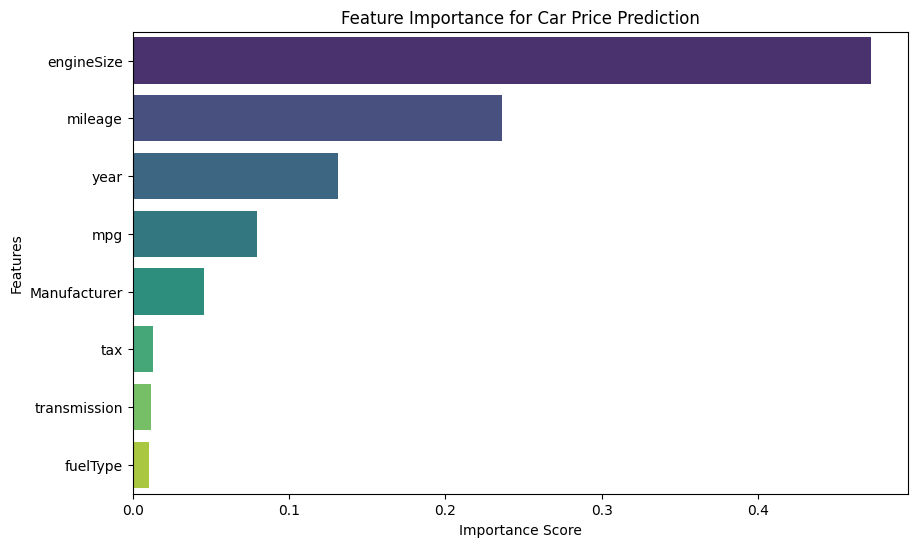

In [68]:
# =====================================
# FEATURE IMPORTANCE VISUALIZATION
# =====================================

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance_df,
    palette="viridis"
)

plt.title("Feature Importance for Car Price Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [69]:

# IMPORT CROSS VALIDATION

from sklearn.model_selection import cross_val_score

In [70]:
# =====================================
# CROSS VALIDATION FOR RANDOM FOREST
# =====================================

# Create Random Forest model
rf_model = RandomForestRegressor()

# Perform 5-fold cross validation
cv_scores = cross_val_score(
    rf_model,
    x,
    y,
    cv=5,                # 5 folds
    scoring='r2'
)

# Print individual fold scores
print("Cross Validation Scores:", cv_scores)

# Print average score
print("Average CV Score:", cv_scores.mean())

Cross Validation Scores: [0.94510539 0.93304507 0.94141904 0.94052555 0.94373617]
Average CV Score: 0.9407662417265257


Random Forest consistently performs well across different splits.

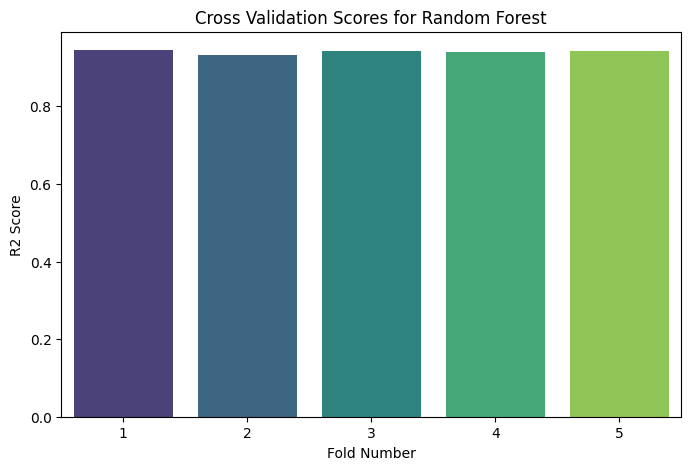

In [71]:
# =====================================
# CROSS VALIDATION VISUALIZATION
# =====================================

plt.figure(figsize=(8,5))

sns.barplot(
    x=list(range(1,6)),
    y=cv_scores,
    palette="viridis"
)

plt.title("Cross Validation Scores for Random Forest")
plt.xlabel("Fold Number")
plt.ylabel("R2 Score")

plt.show()

In [72]:
# =====================================
# IMPORT GRID SEARCH FOR TUNING
# =====================================

from sklearn.model_selection import GridSearchCV

In [73]:
# =====================================
# DEFINE RANDOM FOREST PARAMETERS
# =====================================

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

In [74]:
# =====================================
# GRID SEARCH FOR BEST PARAMETERS
# =====================================

rf = RandomForestRegressor()

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is

In [75]:
# =====================================
# BEST PARAMETERS
# =====================================

print("Best Parameters Found:")
print(grid_search.best_params_)

Best Parameters Found:
{'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}


In [76]:
# =====================================
# TRAIN BEST RANDOM FOREST MODEL
# =====================================

best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(x_test)

tuned_r2 = r2_score(y_test, y_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Tuned Random Forest R2:", tuned_r2)
print("Tuned Random Forest RMSE:", tuned_rmse)

Tuned Random Forest R2: 0.9347967614433403
Tuned Random Forest RMSE: 2519.4074839625478


In [78]:
# =====================================
# PREDICT USING BEST MODEL
# =====================================

# Predict prices using the tuned Random Forest model
y_pred_best = best_rf.predict(x_test)

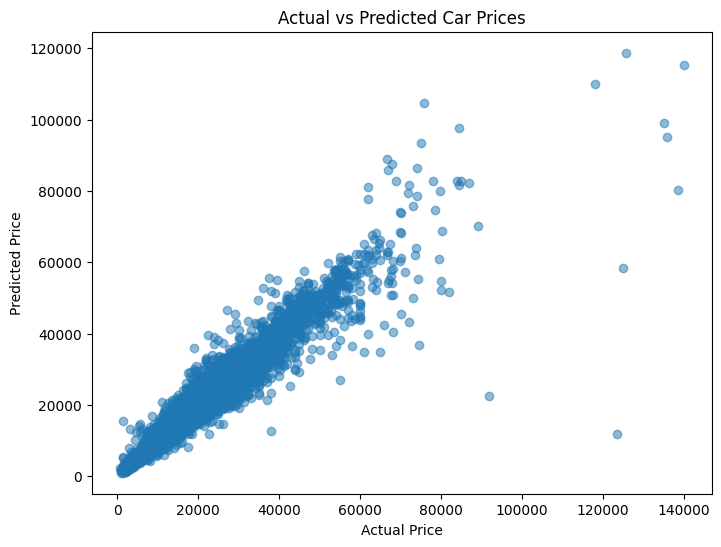

In [79]:
# =====================================
# ACTUAL VS PREDICTED PRICE
# =====================================

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_best, alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

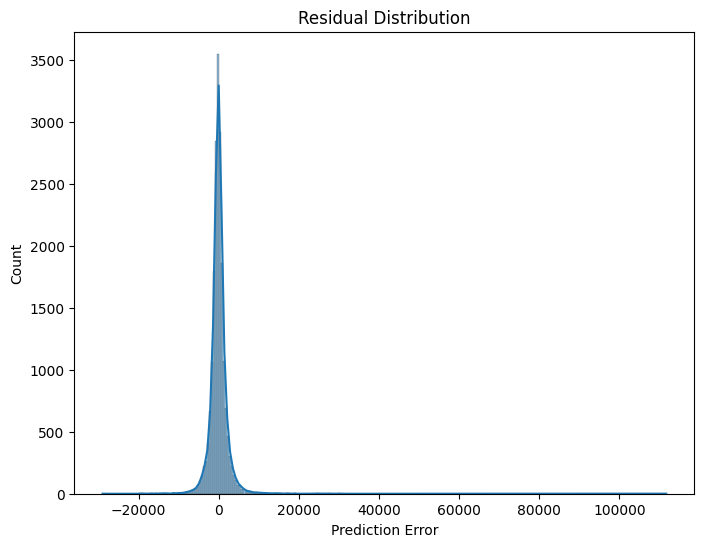

In [80]:
# =====================================
# RESIDUAL ANALYSIS
# =====================================

residuals = y_test - y_pred_best

plt.figure(figsize=(8,6))

sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")
plt.xlabel("Prediction Error")

plt.show()

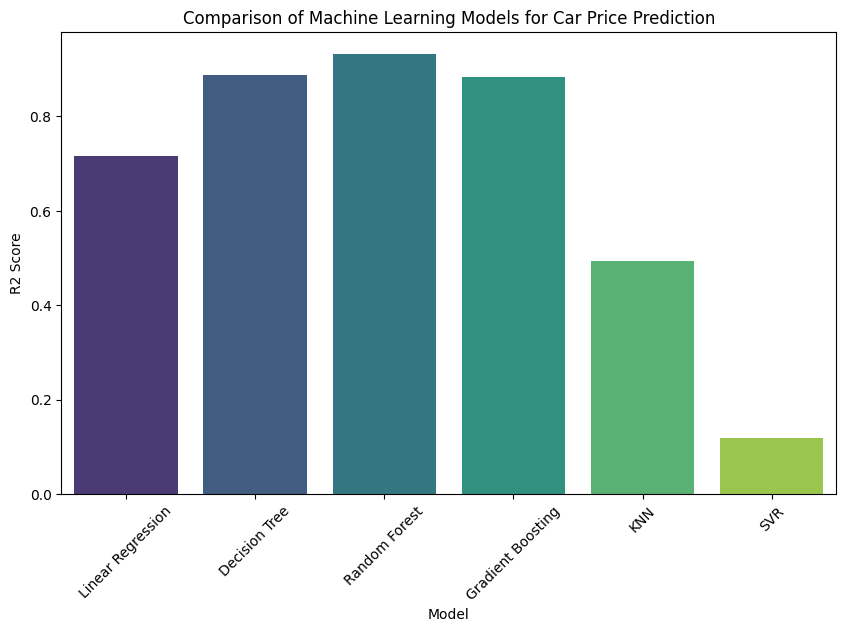

In [81]:
# =====================================
# MODEL PERFORMANCE VISUALIZATION
# =====================================

plt.figure(figsize=(10,6))

sns.barplot(
    x="Model",
    y="R2 Score",
    data=results_df,
    palette="viridis"
)

plt.title("Comparison of Machine Learning Models for Car Price Prediction")

plt.xticks(rotation=45)

plt.show()

In [82]:
# Storing scores in lists
algorithm = [
'LinearRegression',
'DecisionTreeRegressor',
'RandomForestRegressor',
'GradientBoostingRegressor',
'KNN',
'SVR'
]

R2 = [
linear_r2,
dt_r2,
rf_r2,
gb_r2,
knn_r2,
svr_r2
]

RMSE = [
linear_rmse,
dt_rmse,
rf_rmse,
gb_rmse,
knn_rmse,
svr_rmse
]


In [83]:
# Creating DataFrame
df1 = pd.DataFrame({'Algorithm': algorithm, 'R2 Score': R2, 'RMSE': RMSE})
df1

,Algorithm,R2 Score,RMSE
0,LinearRegression,0.715163,5265.773253
1,DecisionTreeRegressor,0.888580,3293.405846
2,RandomForestRegressor,0.932376,2565.755485
3,GradientBoostingRegressor,0.884436,3354.095677
4,KNN,0.493607,7021.144162
5,SVR,0.117747,9267.453774


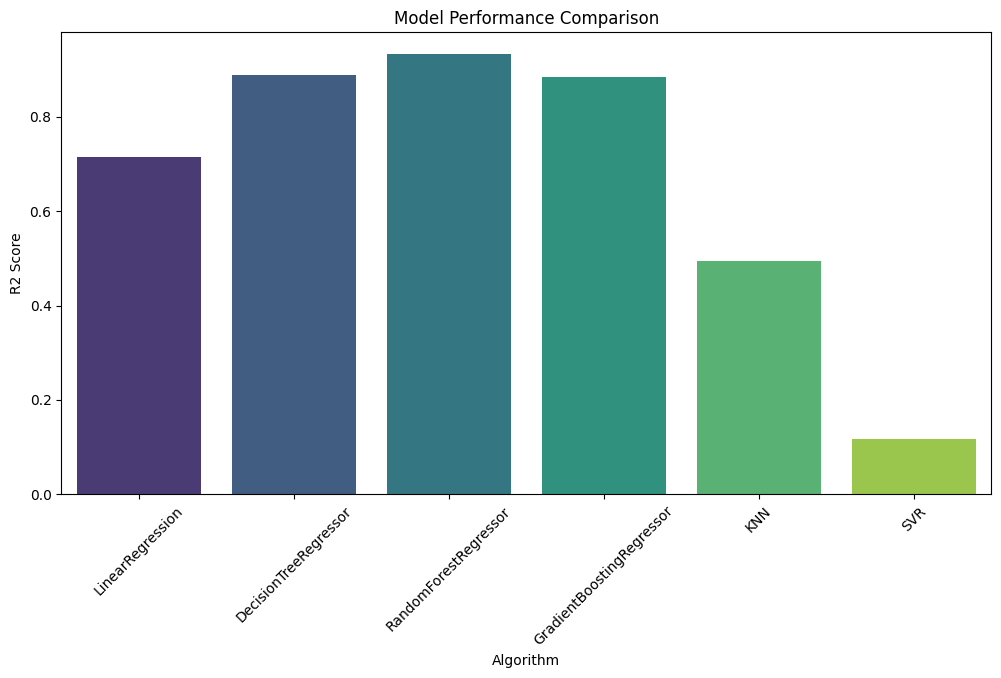

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
x='Algorithm',
y='R2 Score',
data=df1,
palette='viridis'
)

plt.title("Model Performance Comparison")
plt.xticks(rotation=45)

plt.show()

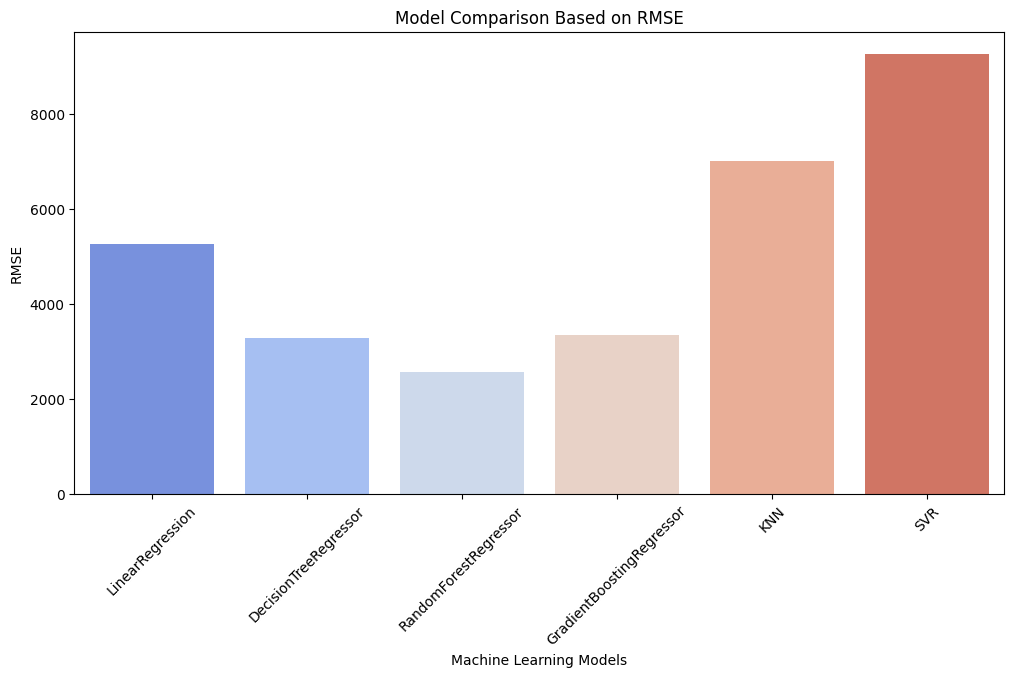

In [85]:
# =====================================
# MODEL COMPARISON USING RMSE
# =====================================

plt.figure(figsize=(12,6))

sns.barplot(
    x='Algorithm',
    y='RMSE',
    data=df1,
    palette='coolwarm'
)

plt.title("Model Comparison Based on RMSE")
plt.xlabel("Machine Learning Models")
plt.ylabel("RMSE")

plt.xticks(rotation=45)

plt.show()

In [87]:
# =====================================
# SAVE FINAL TRAINED MODEL FOR DEPLOYMENT
# =====================================

import joblib

# Save the trained model
joblib.dump(best_rf, "car_price_model.pkl")

# Save feature column order
feature_columns = x.columns.tolist()

joblib.dump(feature_columns, "features.pkl")

['features.pkl']